In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [71]:
import matplotlib.patches as mpatches
import re

In [72]:
df = pd.read_csv("world_bank_Import_Usd_enriched.csv")

In [73]:
df.head()

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster
0,Afghanistan,2024,NaN,Asia,South Asia,Low income,Developing,Asia_Low income
1,Afghanistan,2023,"8,701,650,584.05",Asia,South Asia,Low income,Developing,Asia_Low income
2,Afghanistan,2022,"7,901,784,705.75",Asia,South Asia,Low income,Developing,Asia_Low income
3,Afghanistan,2021,"5,286,118,076.13",Asia,South Asia,Low income,Developing,Asia_Low income
4,Afghanistan,2020,"7,241,822,542.18",Asia,South Asia,Low income,Developing,Asia_Low income


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11067 entries, 0 to 11066
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Country                11067 non-null  object
 1   Year                   11067 non-null  int64 
 2    Imports_Current_USD   7763 non-null   object
 3   Continent              11067 non-null  object
 4   Subregion              11067 non-null  object
 5   Income_Group           11067 non-null  object
 6   Development_Status     11067 non-null  object
 7   Geo_Cluster            11067 non-null  object
dtypes: int64(1), object(7)
memory usage: 691.8+ KB


In [75]:
df.describe()

,Year
count,11067.000000
mean,1999.000000
std,14.720267
min,1974.000000
25%,1986.000000
50%,1999.000000
75%,2012.000000
max,2024.000000


In [76]:
df.isnull().sum()

,0
Country,0
Year,0
Imports_Current_USD,3304
Continent,0
Subregion,0
Income_Group,0
Development_Status,0
Geo_Cluster,0


In [77]:
df['Development_Status'].value_counts()

,count
Development_Status,
Developing,8517
Developed,2550


In [78]:
df['Income_Group'].value_counts()

,count
Income_Group,
High income,4131
Upper middle income,2805
Lower middle income,2601
Low income,1530


In [79]:
df['Continent'].value_counts()

,count
Continent,
Africa,2754
Asia,2499
Europe,2499
North America,1734
Oceania,969
South America,612


In [80]:
df.columns = df.columns.str.strip()

In [81]:
df['Imports_Current_USD'] = df['Imports_Current_USD'].astype(str).str.replace(',', '')

In [82]:
df['Imports_Current_USD'] = pd.to_numeric(df['Imports_Current_USD'], errors='coerce')

In [83]:
df['Imports_Current_USD'] = df['Imports_Current_USD'].fillna(0)

In [84]:
df.head()

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster
0,Afghanistan,2024,0.000000e+00,Asia,South Asia,Low income,Developing,Asia_Low income
1,Afghanistan,2023,8.701651e+09,Asia,South Asia,Low income,Developing,Asia_Low income
2,Afghanistan,2022,7.901785e+09,Asia,South Asia,Low income,Developing,Asia_Low income
3,Afghanistan,2021,5.286118e+09,Asia,South Asia,Low income,Developing,Asia_Low income
4,Afghanistan,2020,7.241823e+09,Asia,South Asia,Low income,Developing,Asia_Low income


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11067 entries, 0 to 11066
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              11067 non-null  object 
 1   Year                 11067 non-null  int64  
 2   Imports_Current_USD  11067 non-null  float64
 3   Continent            11067 non-null  object 
 4   Subregion            11067 non-null  object 
 5   Income_Group         11067 non-null  object 
 6   Development_Status   11067 non-null  object 
 7   Geo_Cluster          11067 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 691.8+ KB


In [86]:
df.isnull().sum()

,0
Country,0
Year,0
Imports_Current_USD,0
Continent,0
Subregion,0
Income_Group,0
Development_Status,0
Geo_Cluster,0


In [87]:
yearly_imports = df.groupby('Year')['Imports_Current_USD'].sum().reset_index()
yearly_imports.head()

,Year,Imports_Current_USD
0,1974,8.752713e+11
1,1975,9.249953e+11
2,1976,1.041732e+12
3,1977,1.196852e+12
4,1978,1.385443e+12


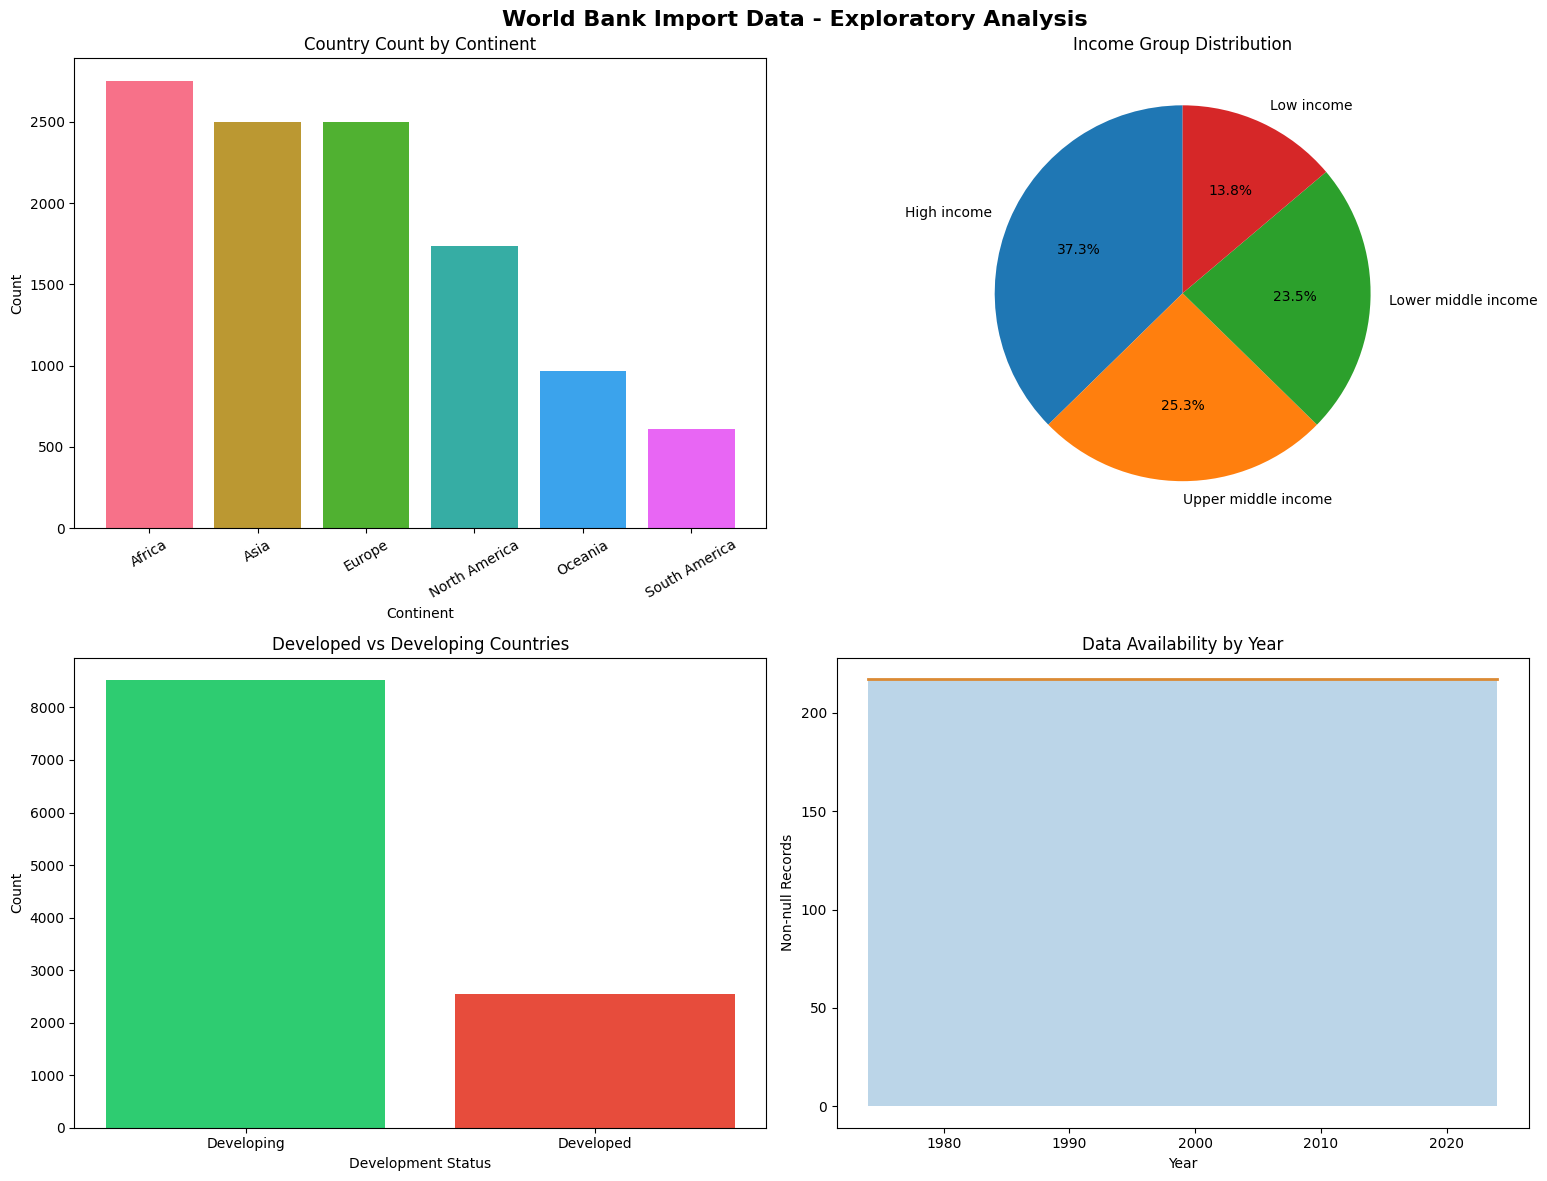

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('World Bank Import Data - Exploratory Analysis', fontsize=16, fontweight='bold')

# Plot 1: Continent wise distribution
continent_counts = df['Continent'].value_counts()
axes[0, 0].bar(continent_counts.index, continent_counts.values, color=sns.color_palette('husl', len(continent_counts)))
axes[0, 0].set_title('Country Count by Continent')
axes[0, 0].set_xlabel('Continent')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=30)

# Plot 2: Income Group distribution
income_counts = df['Income_Group'].value_counts()
axes[0, 1].pie(income_counts.values, labels=income_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Income Group Distribution')

# Plot 3: Development Status
dev_counts = df['Development_Status'].value_counts()
axes[1, 0].bar(dev_counts.index, dev_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Developed vs Developing Countries')
axes[1, 0].set_xlabel('Development Status')
axes[1, 0].set_ylabel('Count')

# Plot 4: Data availability by year
year_counts = df.groupby('Year')['Imports_Current_USD'].count()
axes[1, 1].plot(year_counts.index, year_counts.values, color='#db8a34', linewidth=2)
axes[1, 1].set_title('Data Availability by Year')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Non-null Records')
axes[1, 1].fill_between(year_counts.index, year_counts.values, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()

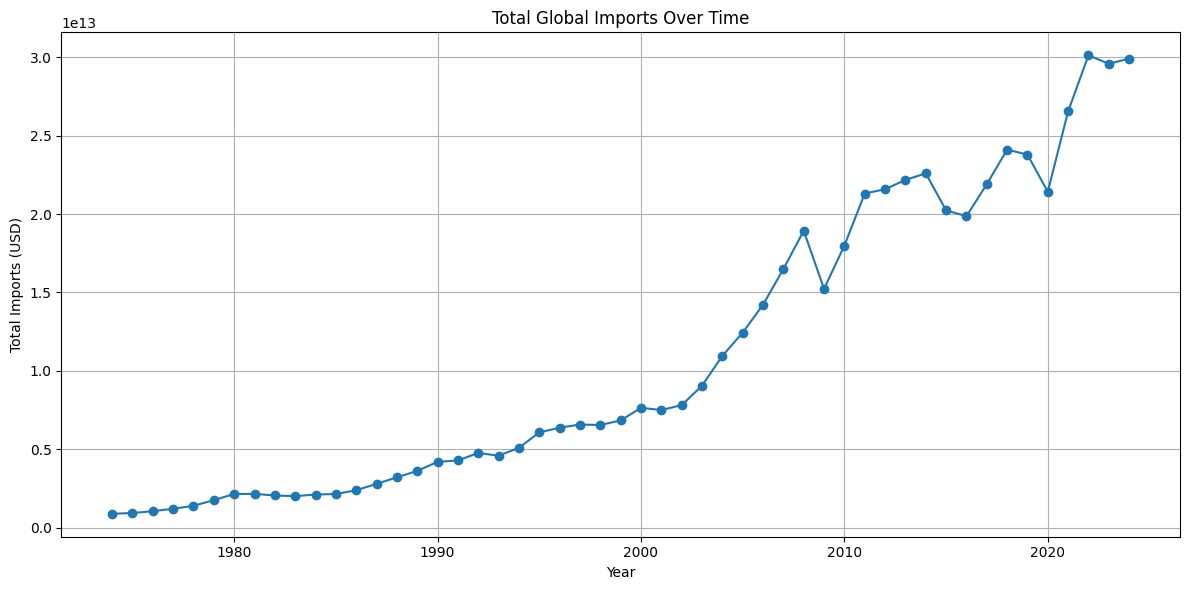

In [89]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_imports['Year'], yearly_imports['Imports_Current_USD'], marker='o', linestyle='-')
plt.title('Total Global Imports Over Time')
plt.xlabel('Year')
plt.ylabel('Total Imports (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [90]:
country_imports = df.groupby('Country')['Imports_Current_USD'].sum().reset_index()
country_imports.head()

,Country,Imports_Current_USD
0,Afghanistan,3.106471e+10
1,Albania,1.552163e+11
2,Algeria,1.371366e+12
3,American Samoa,1.326300e+10
4,Andorra,0.000000e+00


In [91]:
top_10_importers = country_imports.sort_values(by='Imports_Current_USD', ascending=False).head(20)
top_10_importers

,Country,Imports_Current_USD
206,United States,7.926688e+13
41,China,4.342579e+13
73,Germany,3.839064e+13
205,United Kingdom,2.571236e+13
98,Japan,2.519581e+13
68,France,2.477637e+13
139,Netherlands,1.737720e+13
96,Italy,1.717034e+13
35,Canada,1.583406e+13
86,"Hong Kong SAR, China",1.426440e+13


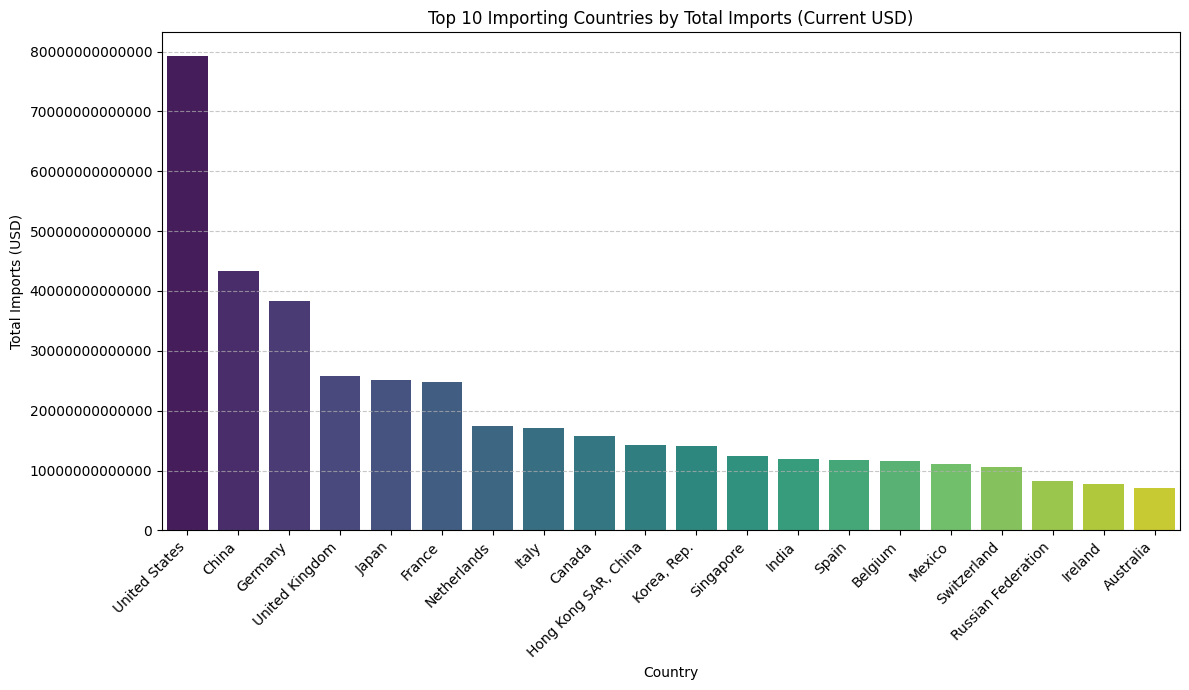

In [92]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Country', y='Imports_Current_USD', data=top_10_importers, palette='viridis')
plt.title('Top 10 Importing Countries by Total Imports (Current USD)')
plt.xlabel('Country')
plt.ylabel('Total Imports (USD)')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Engineering - Naye features banao**

In [93]:
df_clean = df.dropna(subset=['Imports_Current_USD']).copy()

In [94]:
df_clean['Log_Imports'] = np.log1p(df_clean['Imports_Current_USD'])

In [95]:
df_clean['Decade'] = (df_clean['Year'] // 10) * 10

In [96]:
df_clean['Year_Normalized'] = df_clean['Year'] - df_clean['Year'].mean()

In [97]:
df_clean['Geo_Economic'] = df_clean['Continent'] + '_' + df_clean['Income_Group']

In [98]:
df_clean[['Country', 'Year', 'Decade', 'Year_Normalized', 'Geo_Economic']].head()

,Country,Year,Decade,Year_Normalized,Geo_Economic
0,Afghanistan,2024,2020,25.0,Asia_Low income
1,Afghanistan,2023,2020,24.0,Asia_Low income
2,Afghanistan,2022,2020,23.0,Asia_Low income
3,Afghanistan,2021,2020,22.0,Asia_Low income
4,Afghanistan,2020,2020,21.0,Asia_Low income


**Categorical Encoding - Label Encoding karo**

In [99]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.impute import SimpleImputer

In [100]:
le = LabelEncoder()
categorical_cols = ['Continent', 'Subregion', 'Income_Group', 'Development_Status',
                    'Geo_Cluster', 'Country', 'Geo_Economic']

In [101]:
df_encoded = df_clean.copy()

In [102]:
for col in categorical_cols:
    df_encoded[col + '_Encoded'] = le.fit_transform(df_encoded[col].astype(str))
    print(f'  ✓ {col} encoded ({df_encoded[col].nunique()} unique values)')

  ✓ Continent encoded (6 unique values)
  ✓ Subregion encoded (24 unique values)
  ✓ Income_Group encoded (4 unique values)
  ✓ Development_Status encoded (2 unique values)
  ✓ Geo_Cluster encoded (21 unique values)
  ✓ Country encoded (217 unique values)
  ✓ Geo_Economic encoded (21 unique values)


In [103]:
print(f'Total columns now: {df_encoded.shape[1]}')

Total columns now: 19


In [104]:
df_encoded.head()

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster,Log_Imports,Decade,Year_Normalized,Geo_Economic,Continent_Encoded,Subregion_Encoded,Income_Group_Encoded,Development_Status_Encoded,Geo_Cluster_Encoded,Country_Encoded,Geo_Economic_Encoded
0,Afghanistan,2024,0.000000e+00,Asia,South Asia,Low income,Developing,Asia_Low income,0.000000,2020,25.0,Asia_Low income,1,16,1,1,5,0,5
1,Afghanistan,2023,8.701651e+09,Asia,South Asia,Low income,Developing,Asia_Low income,22.886779,2020,24.0,Asia_Low income,1,16,1,1,5,0,5
2,Afghanistan,2022,7.901785e+09,Asia,South Asia,Low income,Developing,Asia_Low income,22.790354,2020,23.0,Asia_Low income,1,16,1,1,5,0,5
3,Afghanistan,2021,5.286118e+09,Asia,South Asia,Low income,Developing,Asia_Low income,22.388350,2020,22.0,Asia_Low income,1,16,1,1,5,0,5
4,Afghanistan,2020,7.241823e+09,Asia,South Asia,Low income,Developing,Asia_Low income,22.703139,2020,21.0,Asia_Low income,1,16,1,1,5,0,5


# REGRESSION MODEL

In [105]:
# Features select karo
reg_features = [
    'Year', 'Decade', 'Year_Normalized',
    'Continent_Encoded', 'Subregion_Encoded',
    'Income_Group_Encoded', 'Development_Status_Encoded',
    'Country_Encoded'
]

In [106]:
X_reg = df_encoded[reg_features]
y_reg = df_encoded['Log_Imports']

In [107]:
print(f'Features used: {reg_features}')
print(f'Total samples: {len(X_reg)}')
print()

Features used: ['Year', 'Decade', 'Year_Normalized', 'Continent_Encoded', 'Subregion_Encoded', 'Income_Group_Encoded', 'Development_Status_Encoded', 'Country_Encoded']
Total samples: 11067



In [108]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [109]:
X_train_r

,Year,Decade,Year_Normalized,Continent_Encoded,Subregion_Encoded,Income_Group_Encoded,Development_Status_Encoded,Country_Encoded
4864,2005,2000,6.0,1,9,0,0,95
9779,1986,1980,-13.0,0,4,2,1,191
5123,2001,2000,2.0,1,3,3,1,100
2405,2016,2010,17.0,0,21,2,1,47
480,2003,2000,4.0,3,0,0,1,9
...,...,...,...,...,...,...,...,...
5734,2002,2000,3.0,0,21,1,1,112
5191,1984,1980,-15.0,0,4,2,1,101
5390,1989,1980,-10.0,2,19,3,1,105
860,1980,1980,-19.0,3,0,0,1,16


In [110]:
X_test_r

,Year,Decade,Year_Normalized,Continent_Encoded,Subregion_Encoded,Income_Group_Encoded,Development_Status_Encoded,Country_Encoded
10100,2022,2020,23.0,1,22,3,1,198
6719,1986,1980,-13.0,1,5,2,1,131
9815,2001,2000,2.0,1,17,3,1,192
3860,1989,1980,-10.0,2,19,0,0,75
4076,1977,1970,-22.0,4,8,0,1,79
...,...,...,...,...,...,...,...,...
5735,2001,2000,2.0,0,21,1,1,112
6743,2013,2010,14.0,2,19,3,1,132
8600,1992,1990,-7.0,2,19,3,1,168
8165,2019,2010,20.0,2,6,0,1,160


In [111]:
scaler = StandardScaler()
X_train_r_scaled = scaler.fit_transform(X_train_r)
X_test_r_scaled = scaler.transform(X_test_r)

# Linear Regression

In [112]:
lr_model = LinearRegression()
lr_model.fit(X_train_r_scaled, y_train_r)
lr_pred = lr_model.predict(X_test_r_scaled)

In [113]:
lr_r2 = r2_score(y_test_r, lr_pred)
lr_mae = mean_absolute_error(y_test_r, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test_r, lr_pred))

In [114]:
print(f'  R² Score: {lr_r2:.4f} (1.0 = perfect)')
print(f'  MAE: {lr_mae:.4f}')
print(f'  RMSE: {lr_rmse:.4f}')
print()

  R² Score: 0.1562 (1.0 = perfect)
  MAE: 8.2669
  RMSE: 9.7060



**Random Forest Regressor (Best Model)**

In [115]:
rf_reg = RandomForestRegressor(
    n_estimators=100,    # 100 trees
    max_depth=15,        # Har tree ki max depth
    min_samples_split=5,
    random_state=42,
    n_jobs=-1            # Sab CPU cores use karo
)

In [116]:
rf_reg.fit(X_train_r, y_train_r)  # RF ko scaling ki zaroorat nahi
rf_pred = rf_reg.predict(X_test_r)

In [117]:
rf_r2 = r2_score(y_test_r, rf_pred)
rf_mae = mean_absolute_error(y_test_r, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_r, rf_pred))

In [118]:
print(f'  R² Score: {rf_r2:.4f} (1.0 = perfect)')
print(f'  MAE: {rf_mae:.4f}')
print(f'  RMSE: {rf_rmse:.4f}')

  R² Score: 0.9189 (1.0 = perfect)
  MAE: 1.4335
  RMSE: 3.0089


# Regression Results Comparison Plot

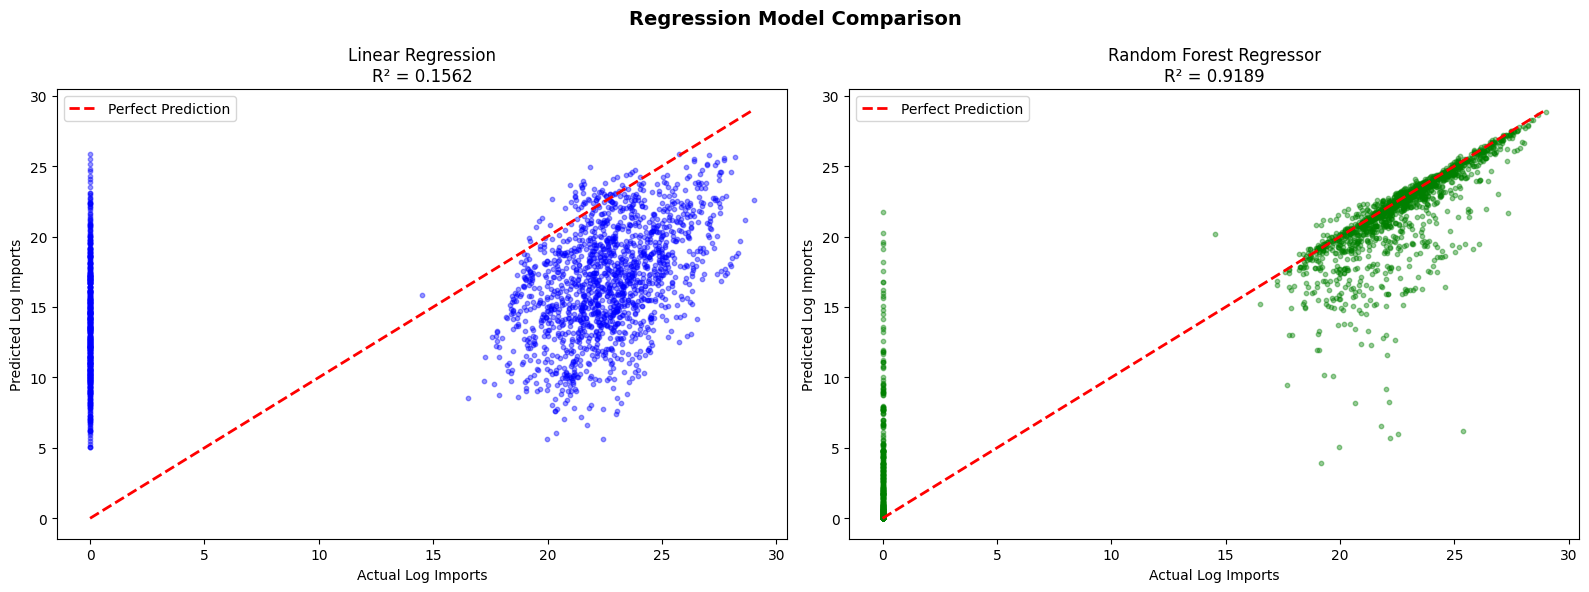


📊 Regression Summary:
Model                     R² Score        MAE          RMSE
------------------------------------------------------------
Linear Regression         0.1562          8.2669       9.7060
Random Forest             0.9189          1.4335       3.0089

🏆 Best Regression Model: Random Forest


In [119]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted (Linear Regression)
axes[0].scatter(y_test_r, lr_pred, alpha=0.4, color='blue', s=10)
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Linear Regression\nR² = {lr_r2:.4f}')
axes[0].set_xlabel('Actual Log Imports')
axes[0].set_ylabel('Predicted Log Imports')
axes[0].legend()

# Plot 2: Actual vs Predicted (Random Forest)
axes[1].scatter(y_test_r, rf_pred, alpha=0.4, color='green', s=10)
axes[1].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_title(f'Random Forest Regressor\nR² = {rf_r2:.4f}')
axes[1].set_xlabel('Actual Log Imports')
axes[1].set_ylabel('Predicted Log Imports')
axes[1].legend()

plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n📊 Regression Summary:')
print(f'{"Model":<25} {"R² Score":<15} {"MAE":<12} {"RMSE"}')
print('-' * 60)
print(f'{"Linear Regression":<25} {lr_r2:<15.4f} {lr_mae:<12.4f} {lr_rmse:.4f}')
print(f'{"Random Forest":<25} {rf_r2:<15.4f} {rf_mae:<12.4f} {rf_rmse:.4f}')
print()
print(f'🏆 Best Regression Model: {"Random Forest" if rf_r2 > lr_r2 else "Linear Regression"}')

# Feature Importance (Random Forest)

In [120]:
feature_importance = pd.DataFrame({
    'Feature': reg_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

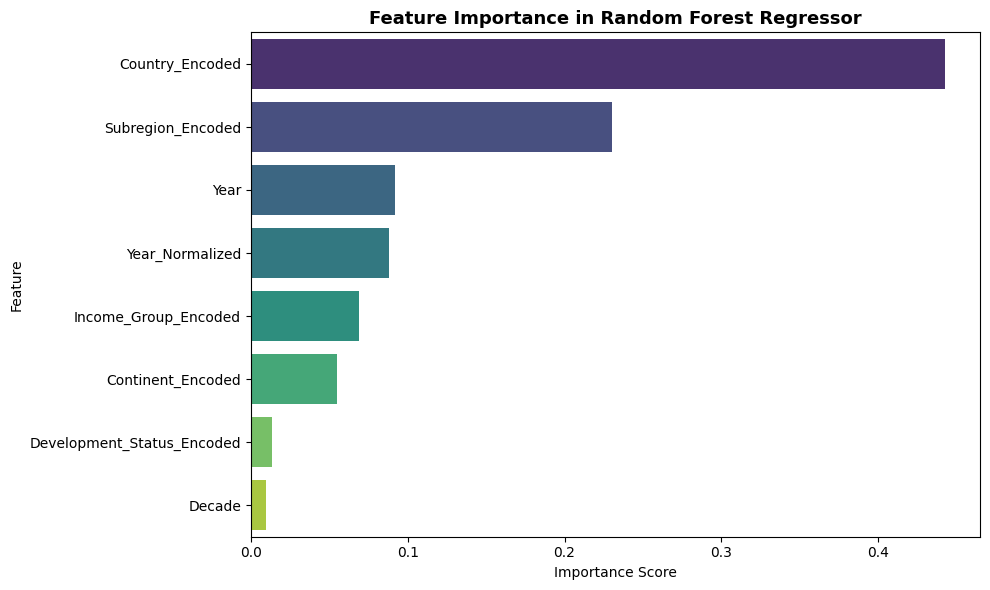

In [121]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in Random Forest Regressor', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_reg.png', dpi=100, bbox_inches='tight')
plt.show()

In [122]:
print(feature_importance)

                      Feature  Importance
7             Country_Encoded    0.442819
4           Subregion_Encoded    0.230256
0                        Year    0.091608
2             Year_Normalized    0.088227
5        Income_Group_Encoded    0.069152
3           Continent_Encoded    0.054779
6  Development_Status_Encoded    0.013745
1                      Decade    0.009413


##  Model 2 - CLASSIFICATION (Developed vs Developing)


In [123]:
clf_features = [
    'Year', 'Log_Imports', 'Decade',
    'Continent_Encoded', 'Subregion_Encoded', 'Income_Group_Encoded'
]

In [124]:
X_clf = df_encoded[clf_features]
y_clf = df_encoded['Development_Status_Encoded']

In [125]:
le_dev = LabelEncoder()
le_dev.fit(df_encoded['Development_Status'])

LabelEncoder()

In [126]:
print(f'Classes: {list(enumerate(le_dev.classes_))}')
print(f'Target value counts: {y_clf.value_counts().to_dict()}')
print(f'Total samples: {len(X_clf)}')

Classes: [(0, 'Developed'), (1, 'Developing')]
Target value counts: {1: 8517, 0: 2550}
Total samples: 11067


In [127]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

In [128]:
print(f'\nTraining set: {len(X_train_c)} | Testing set: {len(X_test_c)}')


Training set: 8853 | Testing set: 2214


# Train Multiple Classification Models

In [129]:
log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_c, y_train_c)
log_pred = log_clf.predict(X_test_c)
log_acc = accuracy_score(y_test_c, log_pred)
print(f'Logistic Regression Accuracy: {log_acc*100:.2f}%')

Logistic Regression Accuracy: 93.59%


In [130]:
# 6.2 Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_clf.fit(X_train_c, y_train_c)
dt_pred = dt_clf.predict(X_test_c)
dt_acc = accuracy_score(y_test_c, dt_pred)
print(f'Decision Tree Accuracy:       {dt_acc*100:.2f}%')

Decision Tree Accuracy:       98.33%


In [131]:
# 6.3 Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
rf_clf_pred = rf_clf.predict(X_test_c)
rf_clf_acc = accuracy_score(y_test_c, rf_clf_pred)
print(f'Random Forest Accuracy:       {rf_clf_acc*100:.2f}%')

Random Forest Accuracy:       98.60%


In [132]:
# 6.4 Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_clf.fit(X_train_c, y_train_c)
gb_pred = gb_clf.predict(X_test_c)
gb_acc = accuracy_score(y_test_c, gb_pred)
print(f'Gradient Boosting Accuracy:   {gb_acc*100:.2f}%')

Gradient Boosting Accuracy:   98.78%


# Best model ka detailed report

In [133]:
models_acc = {
    'Logistic Regression': log_acc,
    'Decision Tree': dt_acc,
    'Random Forest': rf_clf_acc,
    'Gradient Boosting': gb_acc
}
best_model_name = max(models_acc, key=models_acc.get)
print(f'\n🏆 Best Model: {best_model_name} ({models_acc[best_model_name]*100:.2f}%)')
print()

# Best model ka Classification Report
best_pred = rf_clf_pred if best_model_name == 'Random Forest' else gb_pred
print('📋 Detailed Classification Report (Best Model):')
print(classification_report(y_test_c, best_pred,
                            target_names=le_dev.classes_))


🏆 Best Model: Gradient Boosting (98.78%)

📋 Detailed Classification Report (Best Model):
              precision    recall  f1-score   support

   Developed       0.98      0.96      0.97       510
  Developing       0.99      0.99      0.99      1704

    accuracy                           0.99      2214
   macro avg       0.99      0.98      0.98      2214
weighted avg       0.99      0.99      0.99      2214



# Visualization - Model Comparison + Confusion Matrix

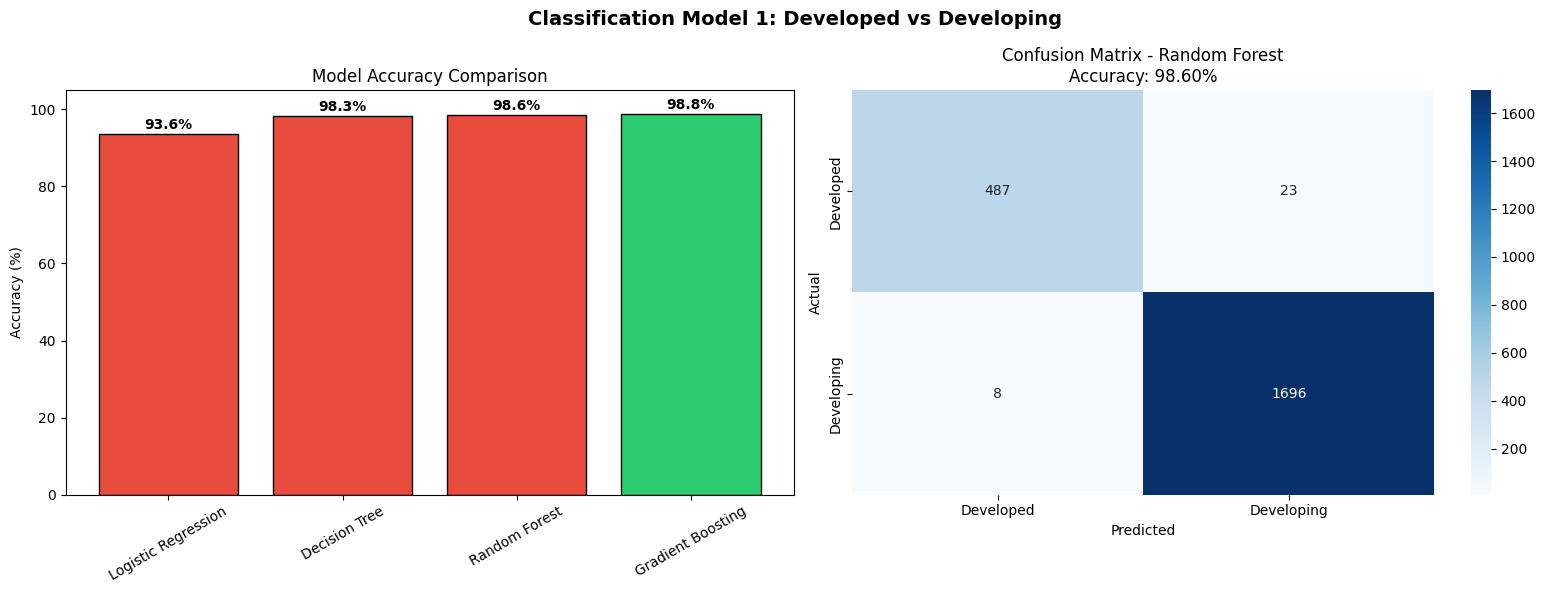

✅ Classification 1 charts ban gaye!


In [134]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Classification Model 1: Developed vs Developing', fontsize=14, fontweight='bold')

# Plot 1: Accuracy Comparison Bar Chart
models = list(models_acc.keys())
accuracies = [v * 100 for v in models_acc.values()]
colors = ['#e74c3c' if m != best_model_name else '#2ecc71' for m in models]
bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 105])
axes[0].tick_params(axis='x', rotation=30)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test_c, rf_clf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le_dev.classes_, yticklabels=le_dev.classes_)
axes[1].set_title(f'Confusion Matrix - Random Forest\nAccuracy: {rf_clf_acc*100:.2f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('classification1_results.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Classification 1 charts ban gaye!')

# Model 3 - CLASSIFICATION (Income Group Predict Karna)

In [135]:
print('🎯 CLASSIFICATION MODEL 2 - Income Group Predict Karna')
print('(Low / Lower Middle / Upper Middle / High Income)')
print('=' * 60)

# Target: Income_Group
income_features = [
    'Year', 'Log_Imports', 'Decade',
    'Continent_Encoded', 'Subregion_Encoded',
    'Development_Status_Encoded'
]

X_inc = df_encoded[income_features]
y_inc = df_encoded['Income_Group_Encoded']

# Check classes
le_inc = LabelEncoder()
le_inc.fit(df_encoded['Income_Group'])
print(f'Income Classes: {list(enumerate(le_inc.classes_))}')
print(f'Distribution: {y_inc.value_counts().to_dict()}')

# Train-Test Split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_inc, y_inc, test_size=0.2, random_state=42, stratify=y_inc
)

print(f'\nTraining: {len(X_train_i)} | Testing: {len(X_test_i)}')

🎯 CLASSIFICATION MODEL 2 - Income Group Predict Karna
(Low / Lower Middle / Upper Middle / High Income)
Income Classes: [(0, 'High income'), (1, 'Low income'), (2, 'Lower middle income'), (3, 'Upper middle income')]
Distribution: {0: 4131, 3: 2805, 2: 2601, 1: 1530}

Training: 8853 | Testing: 2214


# Train Income Group Models

In [136]:
print('🤖 Income Group Models Training...')
print()

# Random Forest (Best for multi-class)
rf_inc = RandomForestClassifier(n_estimators=150, max_depth=20,
                                 min_samples_split=3, random_state=42, n_jobs=-1)
rf_inc.fit(X_train_i, y_train_i)
rf_inc_pred = rf_inc.predict(X_test_i)
rf_inc_acc = accuracy_score(y_test_i, rf_inc_pred)
print(f'Random Forest (Income) Accuracy: {rf_inc_acc*100:.2f}%')

# Gradient Boosting
gb_inc = GradientBoostingClassifier(n_estimators=100, max_depth=6, random_state=42)
gb_inc.fit(X_train_i, y_train_i)
gb_inc_pred = gb_inc.predict(X_test_i)
gb_inc_acc = accuracy_score(y_test_i, gb_inc_pred)
print(f'Gradient Boosting (Income) Accuracy: {gb_inc_acc*100:.2f}%')

# Decision Tree
dt_inc = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_inc.fit(X_train_i, y_train_i)
dt_inc_pred = dt_inc.predict(X_test_i)
dt_inc_acc = accuracy_score(y_test_i, dt_inc_pred)
print(f'Decision Tree (Income) Accuracy:     {dt_inc_acc*100:.2f}%')

🤖 Income Group Models Training...

Random Forest (Income) Accuracy: 78.14%
Gradient Boosting (Income) Accuracy: 79.90%
Decision Tree (Income) Accuracy:     78.36%


# Income Group - Detailed Report + Confusion Matrix

📋 Detailed Report - Random Forest (Income Group):
                     precision    recall  f1-score   support

        High income       0.85      0.89      0.87       827
         Low income       0.73      0.79      0.76       306
Lower middle income       0.74      0.74      0.74       520
Upper middle income       0.74      0.65      0.69       561

           accuracy                           0.78      2214
          macro avg       0.76      0.77      0.77      2214
       weighted avg       0.78      0.78      0.78      2214



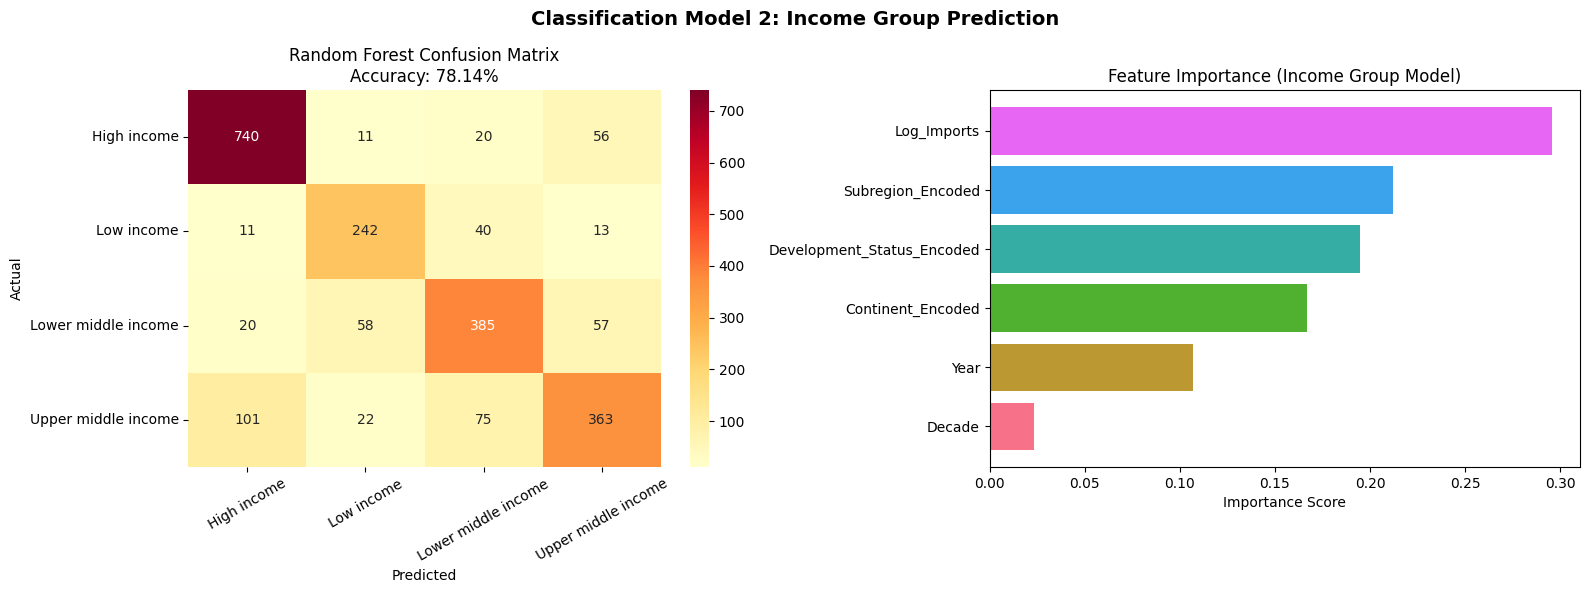

✅ Income Group charts ban gaye!


In [137]:
print('📋 Detailed Report - Random Forest (Income Group):')
print(classification_report(y_test_i, rf_inc_pred, target_names=le_inc.classes_))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Classification Model 2: Income Group Prediction', fontsize=14, fontweight='bold')

# Confusion Matrix
cm2 = confusion_matrix(y_test_i, rf_inc_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=le_inc.classes_, yticklabels=le_inc.classes_)
axes[0].set_title(f'Random Forest Confusion Matrix\nAccuracy: {rf_inc_acc*100:.2f}%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

# Feature Importance for Income Model
fi_inc = pd.DataFrame({'Feature': income_features,
                        'Importance': rf_inc.feature_importances_}).sort_values('Importance', ascending=True)
axes[1].barh(fi_inc['Feature'], fi_inc['Importance'], color=sns.color_palette('husl', len(income_features)))
axes[1].set_title('Feature Importance (Income Group Model)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('classification2_results.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Income Group charts ban gaye!')

## Cross Validation (Model Ki Reliability Check)

In [138]:
print('🔍 Cross Validation (5-Fold)...')
print('Ye step confirm karta hai ki model genuinely accha hai')
print()

# Regression - Random Forest CV
cv_rf_reg = cross_val_score(rf_reg, X_reg, y_reg, cv=5, scoring='r2', n_jobs=-1)
print(f'Regression (Random Forest) CV R² Scores: {cv_rf_reg.round(4)}')
print(f'  Mean R²: {cv_rf_reg.mean():.4f} ± {cv_rf_reg.std():.4f}')
print()

# Classification 1 - Random Forest CV
cv_rf_clf = cross_val_score(rf_clf, X_clf, y_clf, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Classification Dev Status (RF) CV Accuracy: {cv_rf_clf.round(4)}')
print(f'  Mean Accuracy: {cv_rf_clf.mean()*100:.2f}% ± {cv_rf_clf.std()*100:.2f}%')
print()

# Classification 2 - Random Forest CV
cv_rf_inc = cross_val_score(rf_inc, X_inc, y_inc, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Classification Income Group (RF) CV Accuracy: {cv_rf_inc.round(4)}')
print(f'  Mean Accuracy: {cv_rf_inc.mean()*100:.2f}% ± {cv_rf_inc.std()*100:.2f}%')

🔍 Cross Validation (5-Fold)...
Ye step confirm karta hai ki model genuinely accha hai

Regression (Random Forest) CV R² Scores: [-0.0379 -0.1197 -0.1008 -0.2457  0.2912]
  Mean R²: -0.0426 ± 0.1800

Classification Dev Status (RF) CV Accuracy: [0.9232 0.977  0.9715 0.9467 0.9638]
  Mean Accuracy: 95.64% ± 1.95%

Classification Income Group (RF) CV Accuracy: [0.6563 0.6373 0.6231 0.5956 0.6019]
  Mean Accuracy: 62.28% ± 2.24%


## Final Results Summary

In [139]:
print('=' * 65)
print('           🏆 FINAL PROJECT RESULTS SUMMARY 🏆')
print('=' * 65)
print()
print('📌 REGRESSION MODEL (Import Value Predict Karna)')
print(f'   Linear Regression R²:      {lr_r2*100:.2f}%')
print(f'   Random Forest R²:          {rf_r2*100:.2f}%  ← BEST')
print(f'   CV Mean R²:                {cv_rf_reg.mean()*100:.2f}%')
print()
print('📌 CLASSIFICATION 1 (Developed vs Developing)')
print(f'   Logistic Regression:       {log_acc*100:.2f}%')
print(f'   Decision Tree:             {dt_acc*100:.2f}%')
print(f'   Random Forest:             {rf_clf_acc*100:.2f}%  ← BEST')
print(f'   Gradient Boosting:         {gb_acc*100:.2f}%')
print(f'   CV Mean Accuracy:          {cv_rf_clf.mean()*100:.2f}%')
print()
print('📌 CLASSIFICATION 2 (Income Group - 4 Classes)')
print(f'   Decision Tree:             {dt_inc_acc*100:.2f}%')
print(f'   Random Forest:             {rf_inc_acc*100:.2f}%  ← BEST')
print(f'   Gradient Boosting:         {gb_inc_acc*100:.2f}%')
print(f'   CV Mean Accuracy:          {cv_rf_inc.mean()*100:.2f}%')
print()
print('=' * 65)
print()
print('📊 KEY INSIGHTS:')
print('  1. Random Forest sabse better perform karta hai')
print('  2. Country_Encoded aur Income_Group sabse important features hain')
print('  3. Log transformation ne regression accuracy improve ki')
print('  4. Cross Validation confirms ki model stable hai')
print()
print('✅ Project Complete!')

           🏆 FINAL PROJECT RESULTS SUMMARY 🏆

📌 REGRESSION MODEL (Import Value Predict Karna)
   Linear Regression R²:      15.62%
   Random Forest R²:          91.89%  ← BEST
   CV Mean R²:                -4.26%

📌 CLASSIFICATION 1 (Developed vs Developing)
   Logistic Regression:       93.59%
   Decision Tree:             98.33%
   Random Forest:             98.60%  ← BEST
   Gradient Boosting:         98.78%
   CV Mean Accuracy:          95.64%

📌 CLASSIFICATION 2 (Income Group - 4 Classes)
   Decision Tree:             78.36%
   Random Forest:             78.14%  ← BEST
   Gradient Boosting:         79.90%
   CV Mean Accuracy:          62.28%


📊 KEY INSIGHTS:
  1. Random Forest sabse better perform karta hai
  2. Country_Encoded aur Income_Group sabse important features hain
  3. Log transformation ne regression accuracy improve ki
  4. Cross Validation confirms ki model stable hai

✅ Project Complete!


##  Final Summary Chart - Sabhi Models ki Accuracy

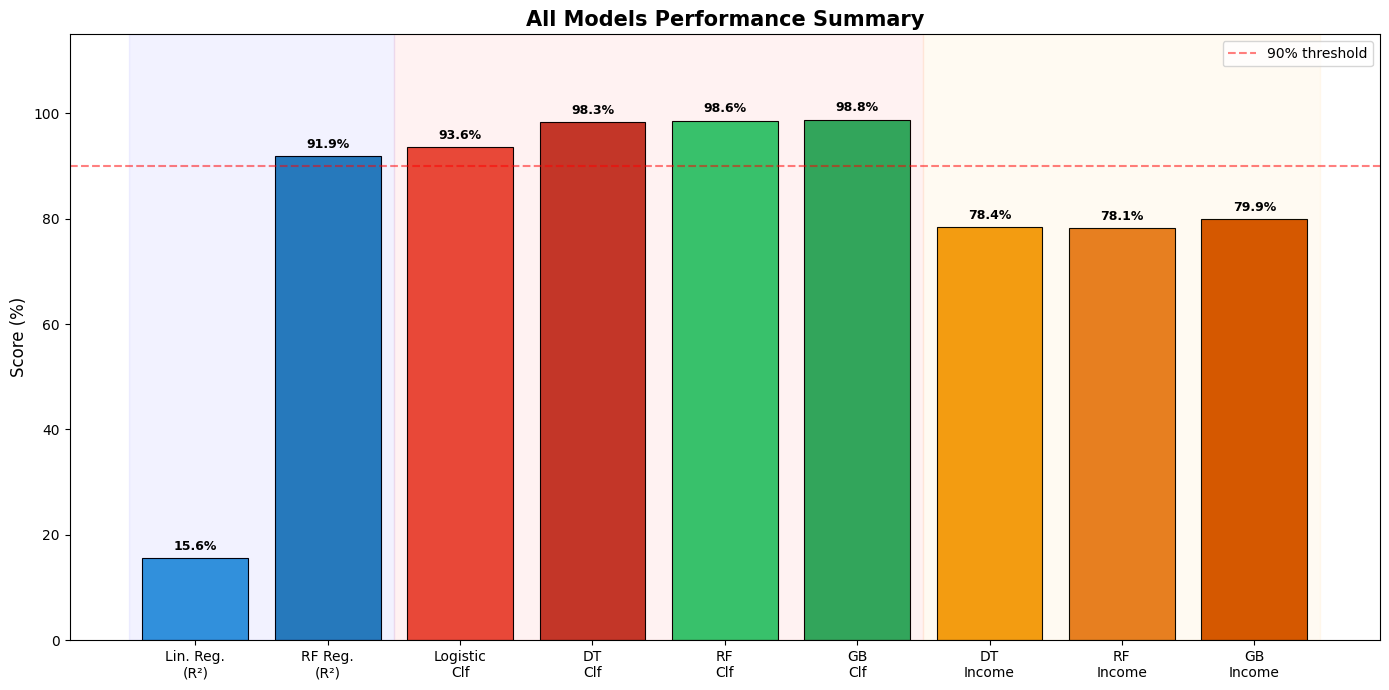

✅ Final Summary Chart complete!


<Figure size 640x480 with 0 Axes>

✅ Final Summary Chart complete!


In [140]:
# Final Summary Chart - Sabhi Models ki Accuracy
fig, ax = plt.subplots(figsize=(14, 7))

all_models = [
    'Lin. Reg.\n(R²)', 'RF Reg.\n(R²)',
    'Logistic\nClf', 'DT\nClf', 'RF\nClf', 'GB\nClf',
    'DT\nIncome', 'RF\nIncome', 'GB\nIncome'
]
all_scores = [
    lr_r2*100, rf_r2*100,
    log_acc*100, dt_acc*100, rf_clf_acc*100, gb_acc*100,
    dt_inc_acc*100, rf_inc_acc*100, gb_inc_acc*100
]
all_colors = ['#3498db', '#2980b9', '#e74c3c', '#c0392b', '#2ecc71', '#27ae60',
              '#f39c12', '#e67e22', '#d35400']

bars = ax.bar(all_models, all_scores, color=all_colors, edgecolor='black', linewidth=0.8)
ax.set_title('All Models Performance Summary', fontsize=15, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim([0, 115])
ax.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
ax.legend()

for bar, score in zip(bars, all_scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{score:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Category labels
ax.axvspan(-0.5, 1.5, alpha=0.05, color='blue', label='Regression')
ax.axvspan(1.5, 5.5, alpha=0.05, color='red', label='Dev. Status')
ax.axvspan(5.5, 8.5, alpha=0.05, color='orange', label='Income Group')

plt.tight_layout()
plt.savefig('final_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Final Summary Chart complete!')

plt.tight_layout()
plt.savefig('final_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Final Summary Chart complete!')

In [141]:
import joblib
joblib.dump(gb_clf, 'best_classification_model.pkl')

['best_classification_model.pkl']